In [1]:
# Import libraries
import os
import time
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

# Copy the needed script from the training code
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225])
])

In [2]:
# Create a GSV dataset
class GSVDataset(Dataset):

    def __init__(self, image_root, transform=None):
        self.samples = []
        self.transform = transform

        for point_folder in sorted(os.listdir(image_root)):

            folder_path = os.path.join(image_root, point_folder)

            if not os.path.isdir(folder_path):
                continue

            point_id = point_folder.replace("point_", "")

            for img in os.listdir(folder_path):

                if img.endswith(".jpg"):

                    img_path = os.path.join(folder_path, img)

                    self.samples.append({
                        "point_id": point_id,
                        "img_path": img_path
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        with Image.open(sample["img_path"]) as img:
            image = img.convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, sample["point_id"]

In [3]:
# Load the trained ResNet50 model
weight_path = r"C:\Users\Azucar\Desktop\Master Thesis\Code\weights\boringness_best.pt"
model = models.resnet50(weights=None)

# Rebuild the classifier head
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2))

model.load_state_dict(torch.load(weight_path, map_location=DEVICE, weights_only=True))

model = model.to(DEVICE)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
# Create GSV Dataloader and process images in batch of 64
GSV_FOLDER = r"C:\Users\Azucar\Desktop\Master Thesis\Data\GSV"

gsv_dataset = GSVDataset(
    GSV_FOLDER,
    transform=val_transform)

gsv_loader = DataLoader(
    gsv_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0)

In [5]:
# Run Inference
def predict_gsv(model, dataloader):

    results = []

    with torch.no_grad():

        for images, point_ids in tqdm(dataloader):

            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1) # Convert logits to probabilities
            boringness_prob = probs[:,1]
            for pid, prob in zip(point_ids, boringness_prob): # Store prediction for each image
                results.append({
                    "point_id": pid,
                    "probability": prob.item()})

    return pd.DataFrame(results)

df_predictions = predict_gsv(model, gsv_loader)
print("Total predicted images:", len(df_predictions))
print(df_predictions["probability"].describe())

100%|██████████████████████████████████████████████████████████████████████████████| 1234/1234 [10:58<00:00,  1.87it/s]

Total predicted images: 78970
count    78970.000000
mean         0.326382
std          0.177656
min          0.027302
25%          0.194628
50%          0.290999
75%          0.421050
max          0.989903
Name: probability, dtype: float64


In [6]:
# Aggregate the 8 scores for each point using mean v.s. median
df_point_scores = df_predictions.groupby("point_id")["probability"].mean().reset_index()

df_point_scores.rename(
    columns={"probability":"boringness_score"},
    inplace=True)

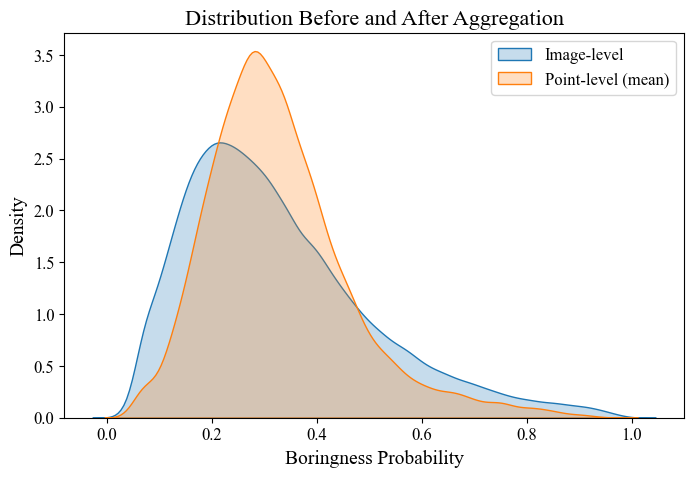

In [7]:
import seaborn as sns

# Plot kernel density plot
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})
plt.figure(figsize=(8,5))

sns.kdeplot(df_predictions["probability"], label="Image-level", fill=True)
sns.kdeplot(df_point_scores["boringness_score"], label="Point-level (mean)", fill=True)

plt.xlabel("Boringness Probability")
plt.ylabel("Density")
plt.title("Distribution Before and After Aggregation")
plt.legend()
plt.show()

In [20]:
# Attach coordinates for mapping
# Load original sampling points
points = pd.read_csv(r"C:\Users\Azucar\Desktop\Master Thesis\Data\sampling_points.csv")

# Recreate the same point_id used during GSV download (0-based index)
points["point_id"] = points.index.astype(int)

# Ensure prediction table has same type
df_point_scores["point_id"] = df_point_scores["point_id"].astype(int)

# Merge predictions with spatial attributes
final_df = points.merge(
    df_point_scores,
    on="point_id",
    how="left")

# Reorganize the columns
final_df = final_df[
    ["point_id",
    "longitude",
    "latitude",
    "fclass",
    "name",
    "Shape_Length",
    "Boringness_score"]]
final_df = final_df.sort_values("point_id")

# Save result
final_df.to_csv("lund_boringness_scores_mean.csv", index=False)

print("Final dataset saved.")

Final dataset saved.
